# Physique des marchés
## TP2.2 : Sélection de stratégies

### Par : Adonis JAMAL

### But
- Appliquer FDR à un ensemble de stratégies.

### Données
- SP500_20161229

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from itertools import product
from scipy import stats

---

### Détection de stratégies valables

1. Données

In [22]:
returns = pd.read_parquet("../data/sp500_20161229.parquet", engine="pyarrow")
returns["index"] = pd.to_datetime(returns["index"])
returns.set_index("index", inplace=True)
returns.head()

,A,AA,AABA,ABC,ABT,ADBE,ADI,ADP,ADSK,AEE,...,WU,WY,XEL,XL,XLNX,XOM,XRX,YUM,ZBH,ZION
index,,,,,,,,,,,,,,,,,,,,,
2006-01-03,0.006308,0.011160,0.044155,0.020773,0.003043,0.049784,0.023139,0.009368,-0.004657,0.012100,...,NaN,0.004522,0.005959,0.012615,0.022213,0.040947,0.017747,-0.002773,0.015421,0.012176
2006-01-04,0.002687,0.005686,0.001467,-0.006626,0.001517,-0.009794,0.009264,0.003238,-0.005951,-0.005013,...,NaN,0.024160,0.004847,0.020519,0.044610,0.001710,-0.001341,0.008556,0.009492,0.007061
2006-01-05,0.026198,0.007981,0.013669,-0.012387,0.010856,-0.009110,0.031857,-0.008391,-0.014722,-0.008527,...,NaN,-0.008791,-0.000536,-0.001867,0.060566,-0.004951,-0.010745,0.042630,-0.010560,0.009089
2006-01-06,0.005222,-0.003299,0.040453,-0.011095,0.021229,0.024429,0.003925,0.008679,0.057798,0.014660,...,NaN,0.001478,0.003753,0.001583,0.019615,0.019732,-0.006110,-0.002848,-0.005117,0.010422
2006-01-09,-0.002886,0.011255,0.004860,0.000000,0.037173,-0.015641,0.014073,-0.002581,-0.014676,-0.004816,...,NaN,-0.002362,-0.002671,0.006752,-0.000687,-0.000505,0.013661,0.007752,0.035415,-0.008277


2. Calculez la performance avec coûts de transaction de 25 couples de paramètres pour la première famille de stratégies du TP2.1 sur chacun des titres des données. Calculez également la performance de 2 stratégies conditionnelles (avec coût de transaction).

In [3]:
# Define strategies
def moving_average_crossover(returns, short_window=20, long_window=50):
    ma_short = returns.rolling(window=short_window).mean()
    ma_long  = returns.rolling(window=long_window).mean()

    signal = pd.DataFrame(0, index=returns.index, columns=returns.columns)
    signal[ma_short > ma_long] = 1
    signal[ma_short < ma_long] = -1
    signal[ma_long.isna()] = 0

    return signal


def conditional_strategy(returns, lookback=20, quantile_threshold=0.1):
    rolling_mean = returns.rolling(window=lookback).mean()

    lower = rolling_mean.expanding().quantile(quantile_threshold)
    upper = rolling_mean.expanding().quantile(1 - quantile_threshold)

    signal = pd.DataFrame(0, index=returns.index, columns=returns.columns)
    signal[rolling_mean > upper] = 1
    signal[rolling_mean < lower] = -1
    signal[rolling_mean.isna()] = 0

    return signal


In [4]:
# Transaction costs
def compute_transaction_costs(signal, cost=0.001):
    return signal.diff().abs()* cost

# Strategy returns
def compute_strategy_returns(returns, signal, cost=0.001):
    gross = signal.shift(1) * returns
    tc = compute_transaction_costs(signal, cost).shift(1)
    return gross - tc

In [5]:
all_strategy_returns = {}

# Moving Average Crossover
short_windows = [5, 10, 20, 50, 100]
long_windows = [110, 150, 200, 250, 300]
ma_params = list(product(short_windows, long_windows))

for s, l in tqdm(ma_params, desc="Moving Average strategies"):
    name = f"MA({s},{l})"
    signal = moving_average_crossover(returns, short_window=s, long_window=l)
    strat_ret = compute_strategy_returns(returns, signal)
    all_strategy_returns[name] = strat_ret

# Conditional strategies
cond_params = [(20, 0.1), (50, 0.25)]

for lookback, qt in tqdm(cond_params, desc="Conditional strategies"):
    name = f"Cond({lookback},{qt})"
    signal = conditional_strategy(returns, lookback=lookback, quantile_threshold=qt)
    strat_ret = compute_strategy_returns(returns, signal)
    all_strategy_returns[name] = strat_ret


Conditional strategies: 100%|██████████| 2/2 [00:02<00:00,  1.33s/it]


In [6]:
rows = []
for strat_name, ret_df in all_strategy_returns.items():
    mean_ret = ret_df.mean()
    sharpe = mean_ret / ret_df.std() * np.sqrt(252)
    for stock in returns.columns:
        rows.append({
            "Strategy": strat_name,
            "Stock": stock,
            "Mean Daily Return": mean_ret[stock],
            "Sharpe Ratio": sharpe[stock],
        })

performance_df = pd.DataFrame(rows)
performance_df.head(10)

,Strategy,Stock,Mean Daily Return,Sharpe Ratio
0,"MA(5,110)",A,-0.000047,-0.037808
1,"MA(5,110)",AA,-0.000548,-0.278555
2,"MA(5,110)",AABA,-0.001246,-0.831551
3,"MA(5,110)",ABC,-0.000527,-0.549406
4,"MA(5,110)",ABT,-0.000767,-0.974652
5,"MA(5,110)",ADBE,-0.001022,-0.796021
6,"MA(5,110)",ADI,-0.001476,-1.291371
7,"MA(5,110)",ADP,-0.000647,-0.782741
8,"MA(5,110)",ADSK,-0.000121,-0.081558
9,"MA(5,110)",AEE,-0.000686,-0.807446


Strategy              Pos. Return  Pos. Sharpe    Total   % Return   % Sharpe
----------------------------------------------------------------------------
Cond(20,0.1)                   53           53      328      16.2%      16.2%
Cond(50,0.25)                  46           46      328      14.0%      14.0%
MA(10,110)                     32           32      328       9.8%       9.8%
MA(10,150)                     39           39      328      11.9%      11.9%
MA(10,200)                     32           32      328       9.8%       9.8%
MA(10,250)                     33           33      328      10.1%      10.1%
MA(10,300)                     37           37      328      11.3%      11.3%
MA(100,110)                    37           37      328      11.3%      11.3%
MA(100,150)                   114          114      328      34.8%      34.8%
MA(100,200)                   115          115      328      35.1%      35.1%
MA(100,250)                   111          111      328      33.8

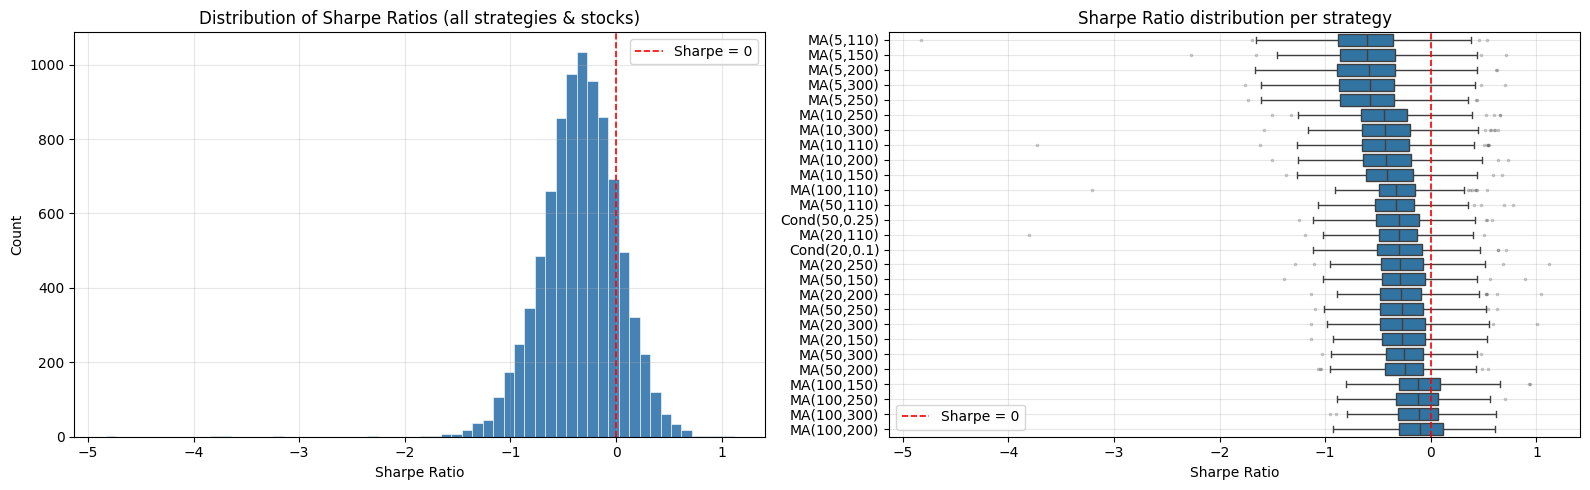

In [7]:
summary = performance_df.groupby("Strategy").agg(
    Positive_Mean_Return=("Mean Daily Return", lambda x: (x > 0).sum()),
    Positive_Sharpe=("Sharpe Ratio", lambda x: (x > 0).sum()),
    Total_Stocks=("Stock", "count"),
)
summary["Pct_Positive_Return"] = summary["Positive_Mean_Return"] / summary["Total_Stocks"]
summary["Pct_Positive_Sharpe"] = summary["Positive_Sharpe"] / summary["Total_Stocks"]

print(f"{'Strategy':<20} {'Pos. Return':>12} {'Pos. Sharpe':>12} {'Total':>8} {'% Return':>10} {'% Sharpe':>10}")
print("-" * 76)
for strat, row in summary.iterrows():
    print(f"{strat:<20} {int(row['Positive_Mean_Return']):>12} {int(row['Positive_Sharpe']):>12} {int(row['Total_Stocks']):>8} {row['Pct_Positive_Return']:>10.1%} {row['Pct_Positive_Sharpe']:>10.1%}")

# Distribution of Sharpe Ratios
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(performance_df["Sharpe Ratio"].dropna(), bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.2, label="Sharpe = 0")
axes[0].set_title("Distribution of Sharpe Ratios (all strategies & stocks)")
axes[0].set_xlabel("Sharpe Ratio")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

strategy_order = performance_df.groupby("Strategy")["Sharpe Ratio"].median().sort_values().index.tolist()
sns.boxplot(
    data=performance_df,
    x="Sharpe Ratio",
    y="Strategy",
    order=strategy_order,
    ax=axes[1],
    flierprops=dict(marker=".", alpha=0.3, markersize=3),
)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.2, label="Sharpe = 0")
axes[1].set_title("Sharpe Ratio distribution per strategy")
axes[1].set_xlabel("Sharpe Ratio")
axes[1].set_ylabel("")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


<blockquote>

En intégrant les coûts de transaction pour les 27 stratégies (25 moyennes mobiles + 2 conditionnelles), nous observons les performances pour le retour moyen quotidien et le ratio de Sharpe. En terme de retours positifs, les stratégies à moyennes mobiles ayant leurs fenêtres courtes à des périodes plus longues ($A=100$) semblent en général être les plus performantes, avec un nombre plus élevé de titres affichant un retour moyen quotidien positif. 

La distribution des ratios de Sharpe montre que la majorité des stratégies ont des performances négatives, mais les stratégies à moyennes mobiles ayant leurs fenêtres courtes à des périodes plus longues tendent à avoir une proportion plus élevée de titres avec un ratio de Sharpe positif.

Cepedant, le boxplot par stratégie révèle que toutes les stratégies ont une grande variabilité, avec de nombreux titres affichant des ratios de Sharpe négatifs. Cela suggère que même pour les stratégies les plus performantes, il existe encore un risque significatif associé à ces stratégies. 

Par ailleurs, les stratégies à moyennes mobiles avec des périodes plus longues donnent généralement de meilleurs résultats que celles avec des périodes plus courtes, ce qui est cohérent avec l'idée que les tendances à plus long terme sont souvent plus stables et moins sujettes au bruit du marché. 

Les stratégies conditionnelles ne sont pas nécessairement les plus performantes, ce qui suggère que leur complexité supplémentaire ne se traduit pas toujours par une meilleure performance.

</blockquote>

3. Calculez la p-value d'un t-test ($H_0 : 0$, $H_1 : > 0$) pour chaque stratégie et chaque titre sur toute la durée des données.

In [8]:
# t-test
pvalue_rows = []

for strat_name, ret_df in all_strategy_returns.items():
    for stock in returns.columns:
        series = ret_df[stock].dropna()
        t_stat, p = stats.ttest_1samp(series, 0, alternative='greater')
        pvalue_rows.append({
            "Strategy": strat_name,
            "Stock": stock,
            "p-value": p,
        })

pvalues_df = pd.DataFrame(pvalue_rows)
pvalues_df.head(10)

,Strategy,Stock,p-value
0,"MA(5,110)",A,0.553106
1,"MA(5,110)",AA,0.764213
2,"MA(5,110)",AABA,0.998329
3,"MA(5,110)",ABC,0.973783
4,"MA(5,110)",ABT,0.999708
5,"MA(5,110)",ADBE,0.997517
6,"MA(5,110)",ADI,0.999997
7,"MA(5,110)",ADP,0.997131
8,"MA(5,110)",ADSK,0.613329
9,"MA(5,110)",AEE,0.997811


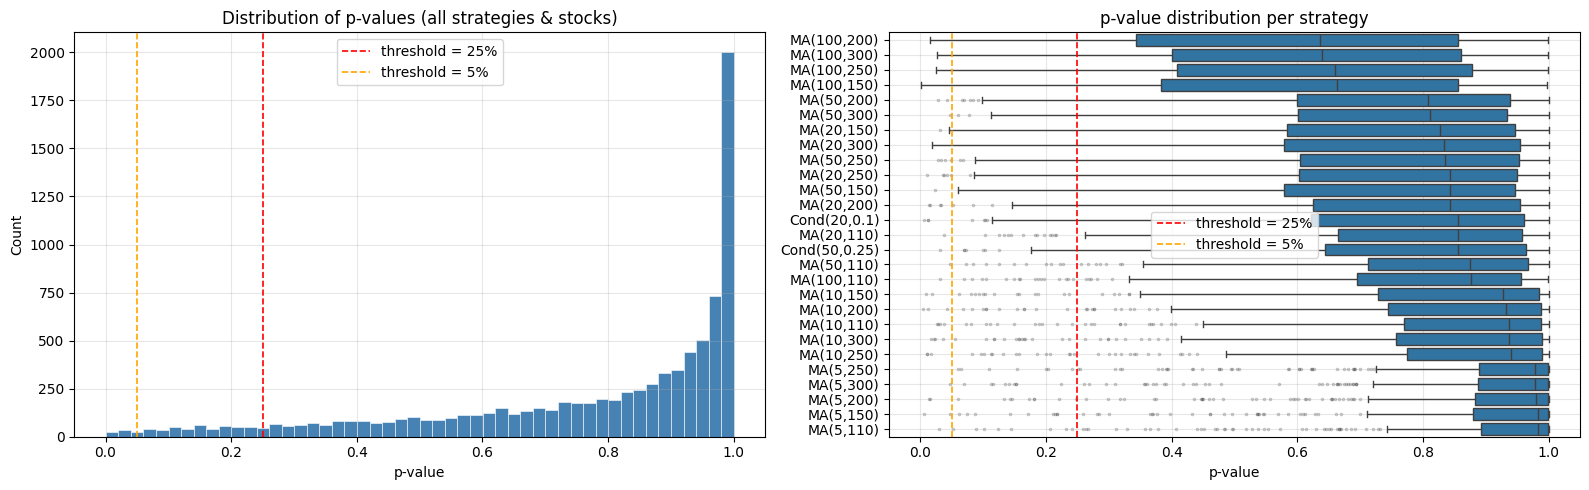

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(pvalues_df["p-value"].dropna(), bins=50, color="steelblue", edgecolor="white", linewidth=0.4)
axes[0].axvline(0.25, color="red", linestyle="--", linewidth=1.2, label="threshold = 25%")
axes[0].axvline(0.05, color="orange", linestyle="--", linewidth=1.2, label="threshold = 5%")
axes[0].set_title("Distribution of p-values (all strategies & stocks)")
axes[0].set_xlabel("p-value")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

strategy_order_pv = pvalues_df.groupby("Strategy")["p-value"].median().sort_values().index.tolist()
sns.boxplot(
    data=pvalues_df,
    x="p-value",
    y="Strategy",
    order=strategy_order_pv,
    ax=axes[1],
    flierprops=dict(marker=".", alpha=0.3, markersize=3),
)
axes[1].axvline(0.25, color="red", linestyle="--", linewidth=1.2, label="threshold = 25%")
axes[1].axvline(0.05, color="orange", linestyle="--", linewidth=1.2, label="threshold = 5%")
axes[1].set_title("p-value distribution per strategy")
axes[1].set_xlabel("p-value")
axes[1].set_ylabel("")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<blockquote>

On observe que la distribution des p-values présente une concentration vers les valeurs élevées. Cette distribution indique que très peu combinaisons (stratégie, titre) présentent des rendements statistiquement différents de zéro.

Le boxplot par stratégie révèle que les stratégies à moyennes mobiles ayant leurs fenêtres courtes à des périodes plus longues tendent à obtenir des p-values moins élevées (plus significatives) que les autres stratégies, ce qui est cohérent avec les performances observées précédemment. Cependant, même pour les stratégies à moyennes mobiles, la grande variabilité des rendements entre les titres dilue la significativité statistique du t-test, ce qui se traduit par des p-values souvent élevées.

Les stratégies à moyennes mobiles avec une fenêtre courte plus longue (e.g., $A=100$) affichent des p-values moins élevées (plus significatives) que celles avec une fenêtre courte plus courte, ce qui est cohérent avec les meilleures performances observées pour ces stratégies.

</blockquote>

4. Fixez un seuil de détection à $25\%$:

(a) Quelle est la fraction des stratégies qui ont une p-valeur plus petite que $25\%$?

In [10]:
threshold = 0.25

selected = pvalues_df[pvalues_df["p-value"] < threshold]
fraction_below = (pvalues_df["p-value"] < threshold).mean()

print(f"Fraction of strategies with p-value < {threshold:.0%} : {fraction_below:.4f} ({fraction_below:.2%})")
print(f"Number of selected strategies: {len(selected)} / {len(pvalues_df)}")

Fraction of strategies with p-value < 25% : 0.0601 (6.01%)
Number of selected strategies: 532 / 8856


Threshold: 5% - Selected: 74 / 8856 (0.84%)
Threshold: 10% - Selected: 158 / 8856 (1.78%)
Threshold: 15% - Selected: 275 / 8856 (3.11%)
Threshold: 20% - Selected: 403 / 8856 (4.55%)
Threshold: 25% - Selected: 532 / 8856 (6.01%)
Threshold: 30% - Selected: 678 / 8856 (7.66%)
Threshold: 35% - Selected: 832 / 8856 (9.39%)
Threshold: 40% - Selected: 1032 / 8856 (11.65%)
Threshold: 45% - Selected: 1226 / 8856 (13.84%)
Threshold: 50% - Selected: 1458 / 8856 (16.46%)


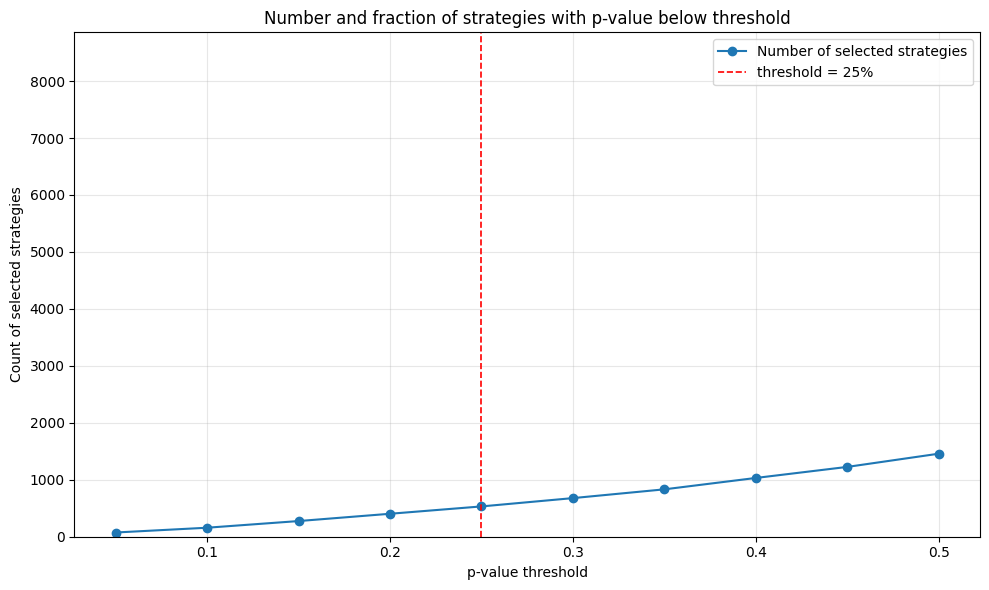

In [11]:
thresholds = np.arange(0.05, 0.55, 0.05)
res = {}

for thres in thresholds:
    selected_thres = pvalues_df[pvalues_df["p-value"] < thres]
    fraction_below = (pvalues_df["p-value"] < thres).mean()
    res[thres] = (len(selected_thres), fraction_below)
    print(f"Threshold: {thres:.0%} - Selected: {len(selected_thres)} / {len(pvalues_df)} ({fraction_below:.2%})")

plt.figure(figsize=(10, 6))
plt.plot(list(res.keys()), [x[0] for x in res.values()], marker="o", label="Number of selected strategies")
plt.axvline(0.25, color="red", linestyle="--", linewidth=1.2, label="threshold = 25%")
plt.title("Number and fraction of strategies with p-value below threshold")
plt.xlabel("p-value threshold")
plt.ylabel("Count of selected strategies")
plt.ylim(0, len(pvalues_df))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

(b) Tracez la performance cumulée des stratégies sélectionnées.

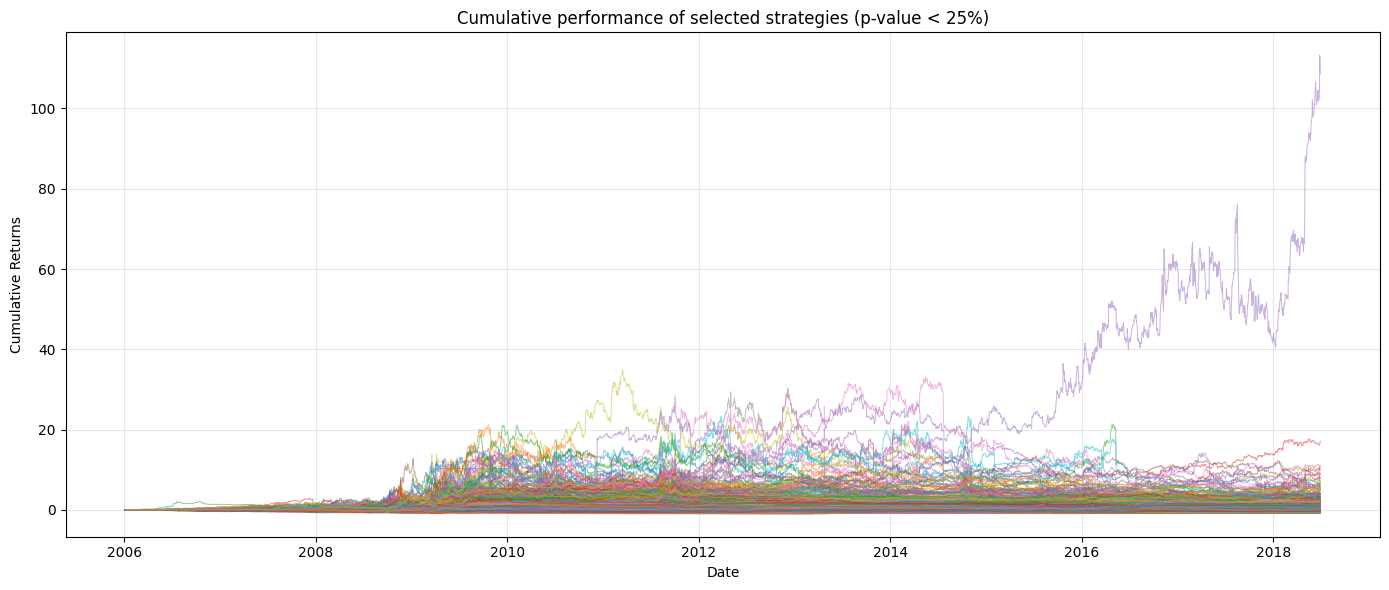

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))

for _, row in selected.iterrows():
    strat = row["Strategy"]
    stock = row["Stock"]
    cum_ret = (1 + all_strategy_returns[strat][stock]).cumprod() - 1
    ax.plot(cum_ret, alpha=0.5, linewidth=0.7)

ax.set_title(f"Cumulative performance of selected strategies (p-value < {threshold:.0%})")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Returns")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<blockquote>

Les stratégies sélectionnées selon ce seuil de $25\%$ présentent une performance cumulée positive au terme de la période d'observation, ce qui suggère que ce seuil permet de retenir des stratégies potentiellement rentables. Cependant, il est important de noter que ce seuil est relativement élevé, et il est probable que de nombreuses stratégies sélectionnées soient en réalité des faux positifs (stratégies qui semblent performantes par hasard).

</blockquote>

5. Appliquez FDR à $25\%$:

(a) Quelle est la fraction des stratégies qui sont sélectionnées ?

In [13]:
fdr_threshold = 0.25

# Filter
valid_mask = pvalues_df["p-value"].notna()
valid_pvalues = pvalues_df[valid_mask].copy()

adjusted = stats.false_discovery_control(valid_pvalues["p-value"].values, method='bh')
valid_pvalues["adjusted p-value"] = adjusted

selected_fdr = valid_pvalues[valid_pvalues["adjusted p-value"] < fdr_threshold]
fraction_fdr = len(selected_fdr) / len(valid_pvalues)

print(f"Fraction of strategies selected with FDR at {fdr_threshold:.0%} : {fraction_fdr:.4f} ({fraction_fdr:.2%})")
print(f"Number of selected strategies : {len(selected_fdr)} / {len(valid_pvalues)}")

Fraction of strategies selected with FDR at 25% : 0.0000 (0.00%)
Number of selected strategies : 0 / 8799


(b) Tracez la performance cumulée des stratégies sélectionnées. Comparer avec le point 4b.

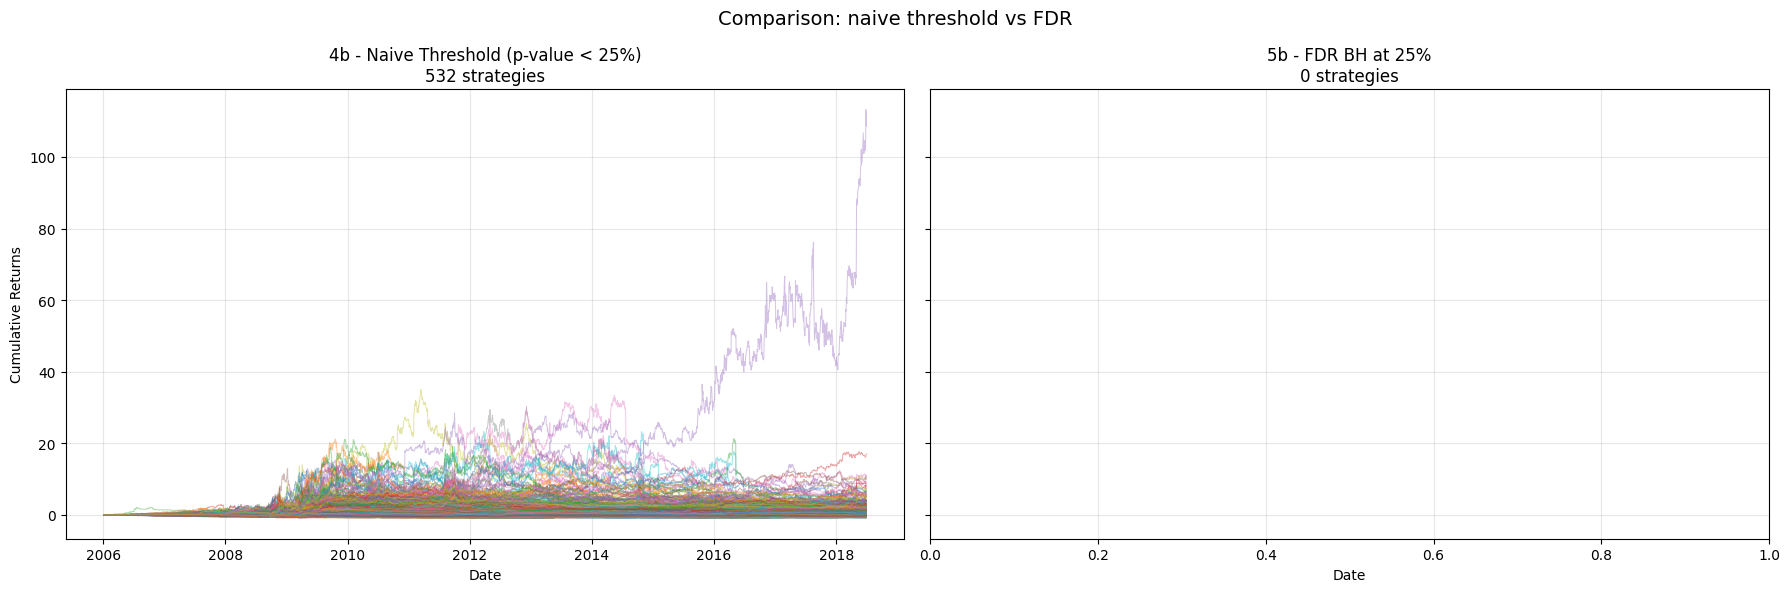

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

for _, row in selected.iterrows():
    cum_ret = (1 + all_strategy_returns[row["Strategy"]][row["Stock"]]).cumprod() - 1
    axes[0].plot(cum_ret, alpha=0.4, linewidth=0.7)
axes[0].set_title(f"4b - Naive Threshold (p-value < {threshold:.0%})\n{len(selected)} strategies")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Cumulative Returns")
axes[0].grid(True, alpha=0.3)

for _, row in selected_fdr.iterrows():
    cum_ret = (1 + all_strategy_returns[row["Strategy"]][row["Stock"]]).cumprod() - 1
    axes[1].plot(cum_ret, alpha=0.4, linewidth=0.7)
axes[1].set_title(f"5b - FDR BH at {fdr_threshold:.0%}\n{len(selected_fdr)} strategies")
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Comparison: naive threshold vs FDR", fontsize=14)
plt.tight_layout()
plt.show()

<blockquote>

Le False Discovery Rate (FDR) à $25\%$ permet de contrôler la proportion de faux positifs parmi les stratégies sélectionnées. En appliquant FDR, nous obtenons zéro stratégies sélectionnées.

Pour expliquer ce résultat, il est important de comprendre que FDR ajuste le seuil de sélection en fonction du nombre total de tests effectués et de la distribution des p-values.

Le t-test effectué donne une large masse vers $1$ et peu de p-values faibles. La procédure de Benjamini-Hochberg utilisée trie les p-values par ordre croissant $p_{(1)} \leq p_{(2)} \leq \ldots \leq p_{(m)}$ et rejette au niveau $k$ si: $$p_{(k)} \leq \frac{k}{m} \cdot \alpha$$ Avec $m$ large ($27$ stratégies x $328$ titres = $8856$ tests), le threshold au niveau $k$ devient très strict, notamment pour les $k$ faibles. Puisque la majorité des p-values sont élevées, les quelques p-values les plus faibles ne satisfont pas la condition de rejet, ce qui conduit à aucune stratégie sélectionnée.

</blockquote>

6. Refaites les points 2 et 3 dans une fenêtre glissante de 252 jours. N.B.: on peut recycler les
calculs du point 2 avec la fonction rolling appliquée aux rendements des stratégies.

(a) Tracez en fonction du temps la fraction des stratégies sélectionnée avec FDR à $25\%$.

In [15]:
window = 252
rolling_pvalues_list = []

# p-values
for strat_name, ret_df in tqdm(all_strategy_returns.items(), desc="rolling p-values"):
    roll_mean = ret_df.rolling(window=window).mean()
    roll_std = ret_df.rolling(window=window).std()
    
    # t-test
    t_stat = np.sqrt(window) * roll_mean / roll_std
    p_val = pd.DataFrame(stats.t.sf(t_stat, df=window-1), index=ret_df.index, columns=ret_df.columns)
    
    p_val.columns = [f"{strat_name}_{stock}" for stock in p_val.columns]
    rolling_pvalues_list.append(p_val)

all_rolling_pvalues = pd.concat(rolling_pvalues_list, axis=1)

rolling p-values: 100%|██████████| 27/27 [00:13<00:00,  2.07it/s]


In [16]:
# Rolling FDR
fdr_threshold = 0.25

fraction_list = []
selection_list = []

for date, row in all_rolling_pvalues.iterrows():
    pvals = row.values.astype(float)
    valid_mask = ~np.isnan(pvals)
    valid_pvals = pvals[valid_mask]
    if len(valid_pvals) == 0:
        fraction_list.append(np.nan)
        selection_list.append(np.zeros(len(pvals), dtype=bool))
        continue
    adjusted = stats.false_discovery_control(valid_pvals, method='bh')
    sel = np.zeros(len(pvals), dtype=bool)
    sel[valid_mask] = adjusted < fdr_threshold
    fraction_list.append(sel.sum() / len(valid_pvals))
    selection_list.append(sel)

fraction_series = pd.Series(fraction_list, index=all_rolling_pvalues.index).dropna()

selection_matrix = pd.DataFrame(
    np.array(selection_list),
    index=all_rolling_pvalues.index,
    columns=all_rolling_pvalues.columns,
)


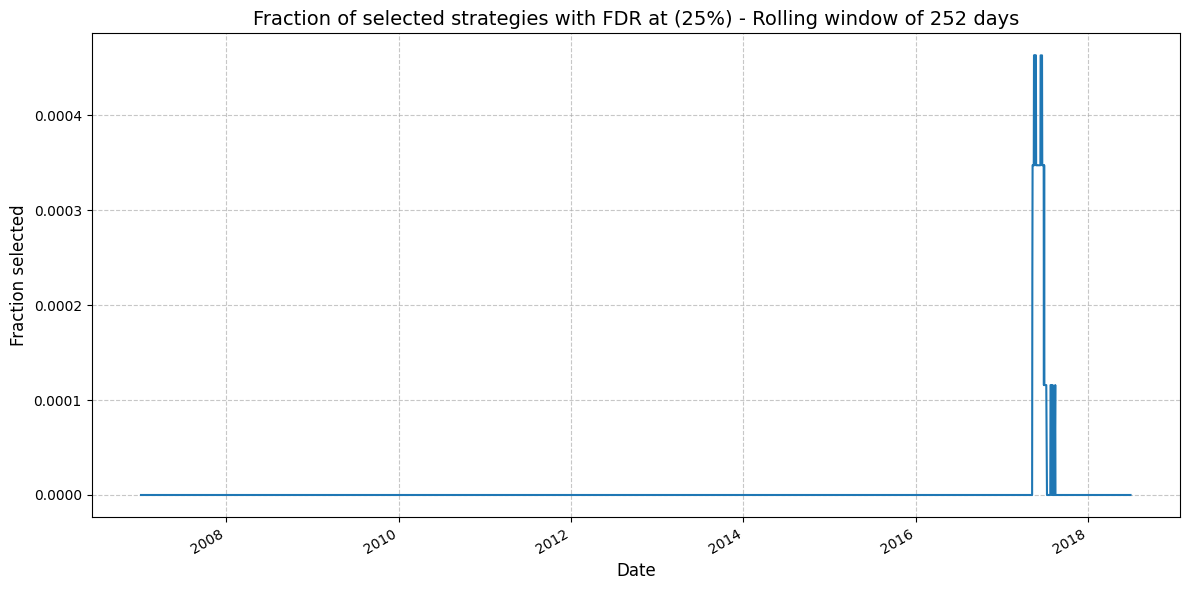

In [17]:
plt.figure(figsize=(12, 6))
fraction_series.plot(linewidth=1.5)
plt.title(f"Fraction of selected strategies with FDR at ({fdr_threshold:.0%}) - Rolling window of {window} days", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Fraction selected", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [18]:
total_pairs = selection_matrix.shape[1]
daily_counts = selection_matrix.sum(axis=1)
active_days = daily_counts[daily_counts > 0]

summary_rolling = pd.DataFrame({
    "Metric": [
        "Total (strategy, stock) pairs",
        "Total trading days",
        "Days with ≥ 1 selection",
        "Days with 0 selections",
        "% days active",
        "Mean # selected (active days)",
        "Median # selected (active days)",
        "Max # selected (single day)",
        "Mean fraction selected (active days)",
    ],
    "Value": [
        f"{total_pairs}",
        f"{len(daily_counts)}",
        f"{len(active_days)}",
        f"{(daily_counts == 0).sum()}",
        f"{len(active_days) / len(daily_counts):.1%}",
        f"{active_days.mean():.1f}",
        f"{active_days.median():.0f}",
        f"{int(daily_counts.max())}",
        f"{(active_days / total_pairs).mean():.2%}",
    ]
})

print(f"Rolling FDR summary (threshold = {fdr_threshold:.0%}, window = {window}d)\n")
print(summary_rolling.to_string(index=False))

Rolling FDR summary (threshold = 25%, window = 252d)

                              Metric Value
       Total (strategy, stock) pairs  8856
                  Total trading days  3145
             Days with ≥ 1 selection    48
              Days with 0 selections  3097
                       % days active  1.5%
       Mean # selected (active days)   2.7
     Median # selected (active days)     3
         Max # selected (single day)     4
Mean fraction selected (active days) 0.03%


<blockquote>

Le passage de la sélection à un cadre temporel glissant révèle une dynamique temporelle importante : la fraction de stratégies sélectionnées par FDR n'est pas constante dans le temps, mais varie selon les régimes de marché. On observe des périodes de sélection plus élevée, correspondant à des fenêtres où les rendements sont plus persistants et les signaux statistiquement plus robustes (typiquement lors de tendances directionnelles marquées), alternant avec des périodes de sélection nulle, par exemple dans le cas de marchés chaotiques ou à faible tendance (par exemple autour des crises).

Contrairement aux résultats statiques des points 3 à 5 (où le FDR sélectionnait zéro stratégies sur l'ensemble de la période), la fenêtre glissante de 252 jours permet à certaines stratégies d'émerger localement, sur des sous-périodes favorables. Cela suggère que la performance des stratégies de suivi de tendance est intrinsèquement non-stationnaire et que leur valeur ajoutée est concentrée dans des régimes spécifiques. La gestion dynamique du portefeuille via le FDR glissant est donc préférable à une sélection statique sur l'ensemble de l'historique.

</blockquote>

(b) Calculez le rendement (pas log-rendement) moyen des stratégies pour chaque jour, et tracez la performance totale dans les périodes de test.

In [19]:
# Returns
strat_stock_returns = {}
for col in all_rolling_pvalues.columns:
    for strat_name in all_strategy_returns.keys():
        if col.startswith(strat_name + "_"):
            stock = col[len(strat_name) + 1:]
            strat_stock_returns[col] = all_strategy_returns[strat_name][stock]
            break

all_returns_matrix = pd.DataFrame(strat_stock_returns).reindex(all_rolling_pvalues.index)
selection_shifted = selection_matrix.shift(1).fillna(False).astype(bool)

# Mean return across selected strategies each day
daily_portfolio = all_returns_matrix.where(selection_shifted).mean(axis=1)
cum_portfolio = (1 + daily_portfolio).cumprod() - 1

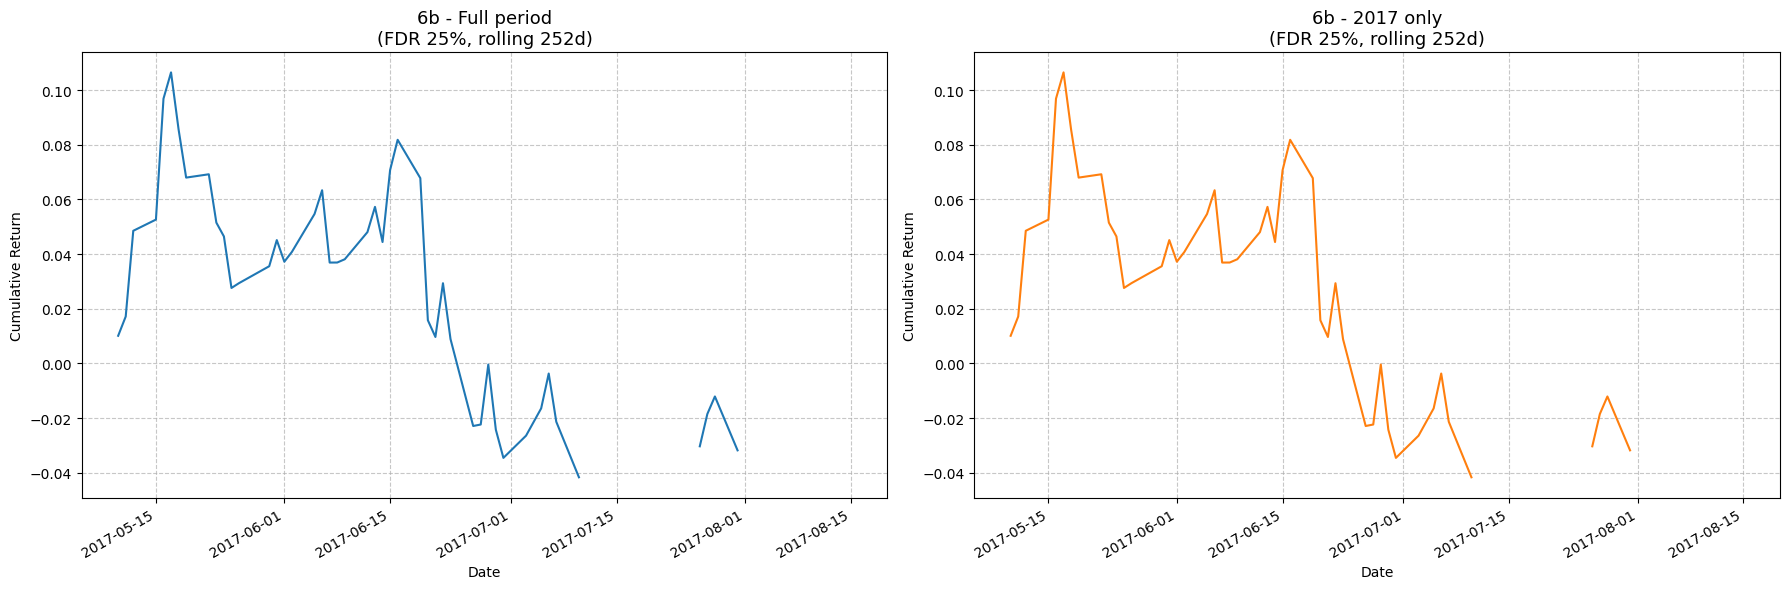

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

cum_portfolio.plot(ax=axes[0], linewidth=1.5)
axes[0].set_title(f"6b - Full period\n(FDR {fdr_threshold:.0%}, rolling {window}d)", fontsize=13)
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Cumulative Return")
axes[0].grid(True, linestyle='--', alpha=0.7)

cum_portfolio_2017 = cum_portfolio["2017"]
cum_portfolio_2017.plot(ax=axes[1], linewidth=1.5, color="tab:orange")
axes[1].set_title(f"6b - 2017 only\n(FDR {fdr_threshold:.0%}, rolling {window}d)", fontsize=13)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Cumulative Return")
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

<blockquote>

On observe que la performance totale des stratégies sélectionnées via FDR glissant est très variable dans le temps, et termine à un niveau négatif. Cela suggère que même si certaines stratégies peuvent émerger localement comme statistiquement significatives dans une fenêtre glissante, leur performance agrégée sur la période complète n'est pas nécessairement positive.

Le fort pic de rendement cumulé observé en mai-juillet 2017, suivi d'une dégradation marquée, est cohérent avec un changement de régime de marché : les stratégies de suivi de tendance (moyennes mobiles) ont naturellement profité des tendances directionnelles post-2016 (bull market), avant d'être pénalisées par les périodes de forte volatilité et de retournements rapides. Ce résultat illustre la non-stationnarité des rendements et la difficulté de maintenir des stratégies statistiquement validées dans le passé sur des horizons longs.

Nous pouvons attribuer cela à un resserrement quantitatif (changement de politique monétaire), des tensions géopolitiques (tensions USA-Corée du Nord) et des rotations sectorielles (notamment tech).

Il est particulièrement intéressant de noter que FDR glissant ne sélectionne aucune stratégie qu'à partir de 2017, ce qui voudrait suggérer que les conditions de marché avant 2017 étaient moins favorables à l'émergence de stratégies de suivi de tendance statistiquement significatives, ou que les signaux étaient plus faibles et plus dispersés, rendant la sélection plus difficile.


</blockquote>

7. Il reste un paramètre, le taux de FDR. Refaites le point 6.b avec une FDR entre $5\%$ et $50\%$ par
palier de $5\%$.

FDR rates: 100%|██████████| 10/10 [01:13<00:00,  7.36s/it]


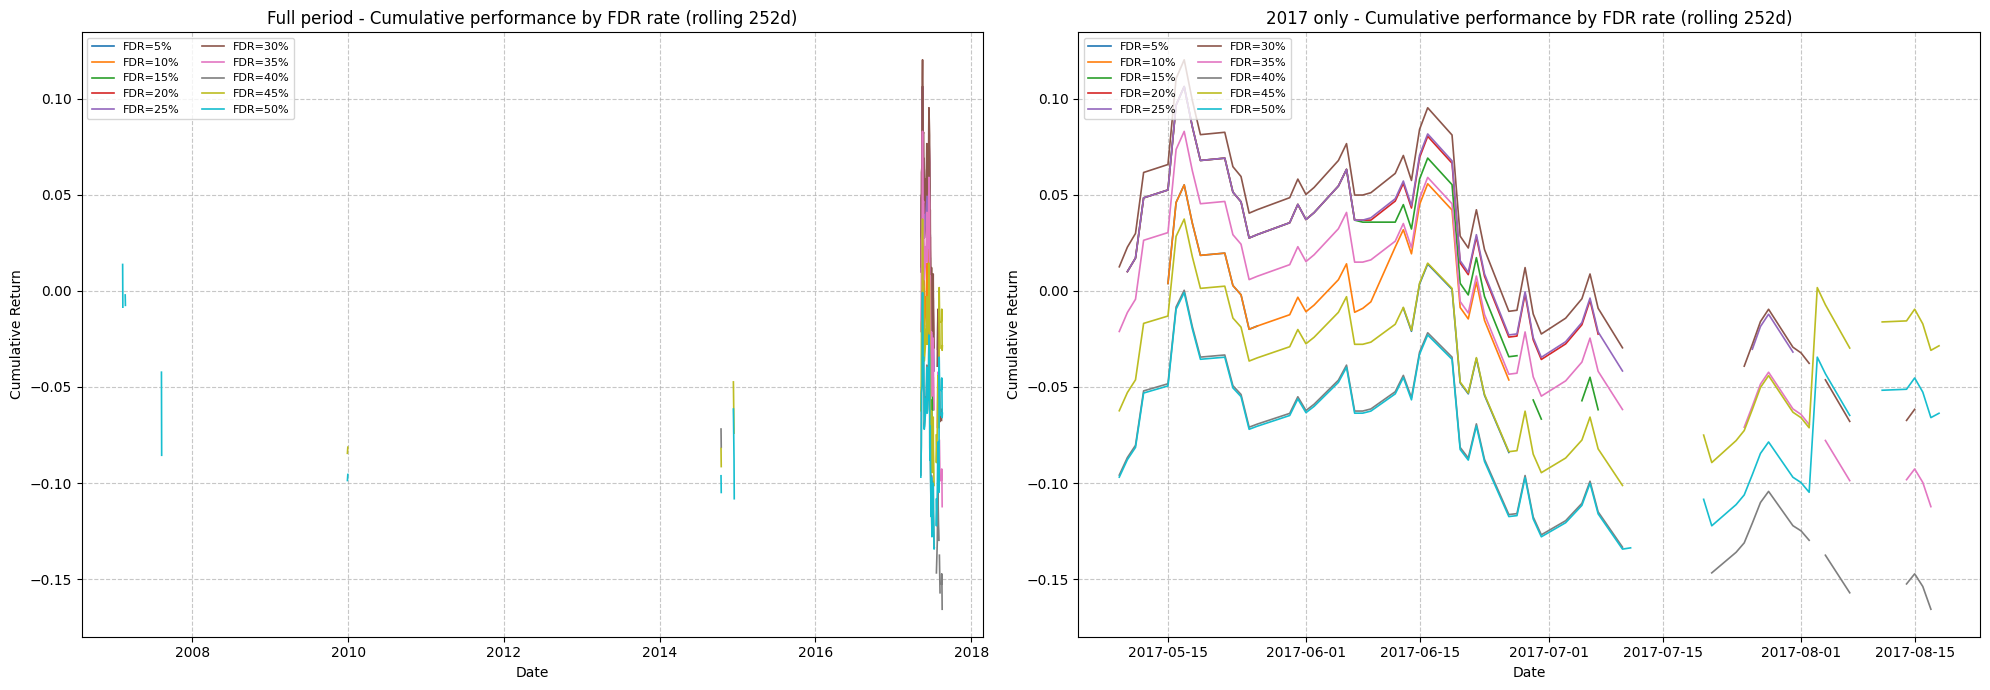

          Avg # Selected / day Avg Fraction Selected  Max # Selected  Min # Selected (non-zero)
FDR Rate                                                                                       
5%                         1.8                 0.02%               3                          1
10%                        2.5                 0.03%               3                          1
15%                        2.5                 0.03%               4                          1
20%                        2.6                 0.03%               4                          1
25%                        2.7                 0.03%               4                          1
30%                        2.7                 0.03%               4                          1
35%                        2.8                 0.03%               5                          1
40%                        2.8                 0.03%               5                          1
45%                        2.9          

In [21]:
fdr_rates = np.arange(0.05, 0.55, 0.05)
summary_rows = []
cum_rets = {}

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for fdr_rate in tqdm(fdr_rates, desc="FDR rates"):
    sel_list = []
    for _, row in all_rolling_pvalues.iterrows():
        pvals = row.values.astype(float)
        valid_mask = ~np.isnan(pvals)
        valid_pvals = pvals[valid_mask]
        if len(valid_pvals) == 0:
            sel_list.append(np.zeros(len(pvals), dtype=bool))
            continue
        adjusted = stats.false_discovery_control(valid_pvals, method='bh')
        sel = np.zeros(len(pvals), dtype=bool)
        sel[valid_mask] = adjusted < fdr_rate
        sel_list.append(sel)

    sel_matrix = pd.DataFrame(
        np.array(sel_list),
        index=all_rolling_pvalues.index,
        columns=all_rolling_pvalues.columns,
    )
    sel_shifted = sel_matrix.shift(1).fillna(False).astype(bool)
    daily_ret = all_returns_matrix.where(sel_shifted).mean(axis=1)
    cum_ret = (1 + daily_ret).cumprod() - 1
    cum_rets[fdr_rate] = cum_ret

    label = f"FDR={fdr_rate:.0%}"
    axes[0].plot(cum_ret, linewidth=1.2, label=label)
    axes[1].plot(cum_ret["2017"], linewidth=1.2, label=label)

    daily_counts = sel_matrix.sum(axis=1)
    total_valid = sel_matrix.shape[1]
    avg_count = daily_counts[sel_matrix.any(axis=1)].mean()
    avg_fraction = avg_count / total_valid
    summary_rows.append({
        "FDR Rate": f"{fdr_rate:.0%}",
        "Avg # Selected / day": avg_count,
        "Avg Fraction Selected": avg_fraction,
        "Max # Selected": int(daily_counts.max()),
        "Min # Selected (non-zero)": int(daily_counts[daily_counts > 0].min()) if (daily_counts > 0).any() else 0,
    })

axes[0].set_title(f"Full period - Cumulative performance by FDR rate (rolling {window}d)", fontsize=12)
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Cumulative Return")
axes[0].legend(loc="upper left", fontsize=8, ncol=2)
axes[0].grid(True, linestyle='--', alpha=0.7)

axes[1].set_title(f"2017 only - Cumulative performance by FDR rate (rolling {window}d)", fontsize=12)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Cumulative Return")
axes[1].legend(loc="upper left", fontsize=8, ncol=2)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

summary_fdr = pd.DataFrame(summary_rows).set_index("FDR Rate")
summary_fdr["Avg # Selected / day"] = summary_fdr["Avg # Selected / day"].round(1)
summary_fdr["Avg Fraction Selected"] = summary_fdr["Avg Fraction Selected"].map("{:.2%}".format)
print(summary_fdr.to_string())

<blockquote>

La variation du taux de FDR permet d'observer comment le nombre de stratégies sélectionnées et leur performance évoluent en fonction du niveau de contrôle des faux positifs. Un taux faible est plus strict et sélectionne moins de stratégies, ce qui peut conduire à une performance plus stable mais potentiellement sous-optimale si des stratégies valables sont rejetées. Un taux plus élevé permet de sélectionner plus de stratégies, mais augmente le risque d'inclure des faux positifs, ce qui peut dégrader la performance globale du portefeuille. Il faut noter que ceci n'est pas linéaire d'après nos résultats, puisque les taux entre $15\%$ et $25\%$ sélectionnent plus de stratégies que les taux plus élevés. La distribution des p-values est en effet pas uniforme.

On observe dans le graphe plus de stratégies par rapport au point 6.b, et les meilleures performances sont obtenues pour les taux de FDR entre $15\%$ et $30\%$. Les taux moins élevés donnent des résultats moins performants, ce qui suggère que le seuil de sélection est trop strict et rejette des stratégies potentiellement rentables. En revanche, les taux plus élevés (au-delà de $30\%$) semblent introduire trop de faux positifs, ce qui dégrade la performance globale du portefeuille. Globalement, toutes les stratégies donnent des performances négatives, ce qui suggère que malgré la sélection de stratégies potentiellement rentables, les conditions de marché n'ont pas été favorables pour ces stratégies sur la période d'observation.

</blockquote>